# Analysis of Change in Twitter Importance Over Time
**Ashley Thompson — Capstone**

Replicates the  Gu & Kurov tests across monthly, quarterly, and annual windows for panel data from 2016–2026, tracking the change in influence Twitter sentiment has on asset prices.

| Test | Spec |
|---|---|
| FMB Return Predictability | `return_oo ~ twitter_sent_lag1 + controls` |
| No-Reversal Test | All 5 sentiment lags jointly |
| Long-Short Strategy | Top/bottom decile Twitter sentiment, daily rebalance |

**Output:** `gk_temporal_monthly.csv`, `gk_temporal_quarterly.csv`, `gk_temporal_annual.csv`

## 1. Install dependencies

In [18]:
!pip install -q linearmodels pandas_datareader statsmodels

## 2. Load data

In [19]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Capstone/'
DATA_PATH = DRIVE_DIR + ('panel_long_extended.csv'
    if os.path.exists(DRIVE_DIR + 'panel_long_extended.csv') else 'panel_long.csv')
print(f'Using: {DATA_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: /content/drive/MyDrive/Colab Notebooks/Capstone/panel_long_extended.csv


In [20]:
from google.colab import userdata
import os, subprocess

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO_DIR     = '/content/Capstone'

if os.path.exists(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)
else:
    subprocess.run(
        ['git', 'clone',
         f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git', REPO_DIR],
        check=True)
DATA_OUT = REPO_DIR + '/data/processed/'
os.makedirs(DATA_OUT, exist_ok=True)
print(f'Repo ready: {REPO_DIR}')

Repo ready: /content/Capstone


## 3. Imports and variable construction

In [21]:
import warnings
import numpy as np
import pandas as pd
from linearmodels.panel import FamaMacBeth

warnings.filterwarnings('ignore')
np.random.seed(42)

long = pd.read_csv(DATA_PATH, parse_dates=['date'])
long = long.sort_values(['ticker', 'date']).reset_index(drop=True)
print(f'Loaded {len(long):,} rows x {long.shape[1]} cols')
print(f'Date range: {long["date"].min().date()} to {long["date"].max().date()}')

HAS_SPREAD = 'bid_ask_spread' in long.columns
print(f'Bid-ask spread: {"AVAILABLE" if HAS_SPREAD else "MISSING"}')

Loaded 1,190,789 rows x 17 cols
Date range: 2016-01-01 to 2026-02-27
Bid-ask spread: AVAILABLE


In [22]:
long['px_open_next'] = long.groupby('ticker')['px_open'].shift(-1)
long['return_oo']    = (long['px_open_next'] - long['px_open']) / long['px_open'] * 100

lH = np.log(long['px_high'].clip(lower=1e-8))
lL = np.log(long['px_low'].clip(lower=1e-8))
lO = np.log(long['px_open'].clip(lower=1e-8))
lC = np.log(long['px_close'].clip(lower=1e-8))
long['vol_rs'] = ((lH-lC)*(lH-lO) + (lL-lC)*(lL-lO)).clip(lower=0) * 100

mv = long.groupby('ticker')['volume'].transform('mean')
long['abnorm_vol']  = ((long['volume'] - mv) / mv) * 100
long['log_mkt_cap'] = np.log(long['mkt_cap'].clip(lower=1e-8))

ctrl_base = ['return_oo', 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
if HAS_SPREAD:
    ctrl_base.append('bid_ask_spread')

for var in ctrl_base:
    for k in range(1, 6):
        long[f'{var}_lag{k}'] = long.groupby('ticker')[var].shift(k)

for k in range(1, 6):
    long[f'twitter_sent_lag{k}'] = long.groupby('ticker')['twitter_sent'].shift(k)

print(f'return_oo: {long["return_oo"].notna().sum():,} obs')
print('Variable construction complete.')

return_oo: 1,190,286 obs
Variable construction complete.


## 4. Fama-French risk adjustment
Betas estimated on the full sample; residuals used within each time window.

In [23]:
import statsmodels.api as sm
import pandas_datareader.data as web

HAS_ADJ_RETURN = False

try:
    s, e = long['date'].min(), long['date'].max()
    ff3  = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=s, end=e)[0]
    mom  = web.DataReader('F-F_Momentum_Factor_daily',       'famafrench', start=s, end=e)[0]
    ff3.index = pd.to_datetime(ff3.index, format='%Y%m%d')
    mom.index = pd.to_datetime(mom.index, format='%Y%m%d')
    ff  = ff3.join(mom, how='inner') / 100
    ff.columns = [c.strip() for c in ff.columns]
    print(f'FF factors: {ff.shape[0]} days, cols: {list(ff.columns)}')

    merged    = long.merge(
        ff.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','Mom':'mom'}),
        left_on='date', right_index=True, how='left')
    residuals = np.full(len(merged), np.nan)
    for ticker, grp in merged.groupby('ticker'):
        sub = grp[['return_oo','mkt_rf','smb','hml','mom']].dropna()
        if len(sub) < 30: continue
        X = sm.add_constant(sub[['mkt_rf','smb','hml','mom']])
        residuals[sub.index] = sm.OLS(sub['return_oo'], X).fit().resid.values
    long['return_oo_adj'] = residuals

    for k in range(1, 6):
        long[f'return_oo_adj_lag{k}'] = long.groupby('ticker')['return_oo_adj'].shift(k)

    HAS_ADJ_RETURN = long['return_oo_adj'].notna().sum() > 1000
    print(f'Risk-adjusted returns: {long["return_oo_adj"].notna().sum():,} obs')

except Exception as ex:
    print(f'FF download failed: {ex}')
    print('Using raw returns throughout.')

DEP_VAR          = 'return_oo_adj' if HAS_ADJ_RETURN else 'return_oo'
DEFAULT_OTH_VARS = ([DEP_VAR, 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
                    + (['bid_ask_spread'] if HAS_SPREAD else []))
print(f'Dependent variable: {DEP_VAR}')
print(f'Confounders:        {DEFAULT_OTH_VARS}')

FF factors: 2553 days, cols: ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']
Risk-adjusted returns: 1,156,294 obs
Dependent variable: return_oo_adj
Confounders:        ['return_oo_adj', 'abnorm_vol', 'vol_rs', 'log_mkt_cap', 'bid_ask_spread']


## 5. Helper functions

In [31]:
# =============================================================
# VARIABLE REFERENCE
# Dependent:   return_oo_adj (risk-adj OO return) or return_oo
# Treatment:   twitter_sent_lag1 (FMB); lags 1-5 (no-reversal)
# Confounders: DEP_VAR, abnorm_vol, vol_rs, log_mkt_cap,
#              bid_ask_spread (if available)
# =============================================================

NR_LAGS = [1, 2, 3, 4, 5]

def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fit_fmb(dep_var, treatment_cols, data, oth_vars=None,
            n_lags=5, bandwidth=5, min_cs=30):
    if oth_vars is None:
        oth_vars = DEFAULT_OTH_VARS
    controls = [f'{v}_lag{k}' for v in oth_vars for k in range(1, n_lags+1)]
    formula  = dep_var + ' ~ ' + ' + '.join(treatment_cols + controls)
    try:
        panel = data.set_index(['ticker','date']) if 'ticker' in data.columns else data
        cs    = panel.groupby(level='date').size()
        valid = set(cs[cs >= min_cs].index)
        for col in treatment_cols + controls:
            if col in panel.columns:
                cv = panel.groupby(level='date')[col].std()
                valid -= set(cv[cv.isna() | (cv == 0)].index)
        panel = panel[panel.index.get_level_values('date').isin(valid)]
        if panel.index.get_level_values('date').nunique() < 10:
            return None
        mod = FamaMacBeth.from_formula(formula, data=panel)
        try:
            return mod.fit(cov_type='kernel', bandwidth=bandwidth)
        except Exception:
            try:    return mod.fit(cov_type='robust')
            except: return None
    except Exception:
        return None

def extract_fmb(res, param):
    if res is None or param not in res.params.index:
        return {'coef': np.nan, 'se': np.nan, 'pval': np.nan, 'stars': ''}
    c, s, pv = float(res.params[param]), float(res.std_errors[param]), float(res.pvalues[param])
    return {'coef': c, 'se': s, 'pval': pv, 'stars': stars(pv)}

def long_short_stats(data):
    df = data[['date','ticker','twitter_sent','return_oo']].dropna().copy()
    df['pct_rank'] = df.groupby('date')['twitter_sent'].rank(pct=True)
    df['side']     = df['pct_rank'].apply(
        lambda r: 'long' if r >= 0.9 else ('short' if r <= 0.1 else None))
    df = df.dropna(subset=['side','return_oo'])
    daily = (df.groupby(['date','side'])['return_oo']
               .mean().unstack('side').dropna(subset=['long','short']))
    if daily.empty:
        return {'ls_mean_daily':np.nan,'ls_ann_return':np.nan,
                'ls_sharpe':np.nan,'ls_win_rate':np.nan,'ls_n_days':0}
    daily['ls'] = daily['long'] - daily['short']
    mu, sigma = daily['ls'].mean(), daily['ls'].std()
    return {'ls_mean_daily': mu, 'ls_ann_return': mu*252,
            'ls_sharpe': (mu/sigma)*np.sqrt(252) if sigma > 0 else np.nan,
            'ls_win_rate': (daily['ls'] > 0).mean(), 'ls_n_days': len(daily)}

def run_window(label, start, end, bandwidth, min_cs):
    sub     = long[(long['date'] >= start) & (long['date'] <= end)].copy()
    n_dates = sub['date'].nunique()
    row     = {'window_label': label, 'window_start': start.date(),
               'window_end': end.date(), 'n_dates': n_dates,
               'n_obs': len(sub), 'dep_var': DEP_VAR}

    nan_cols = (['fmb_coef','fmb_se','fmb_pval','fmb_stars']
                + [f'nr_lag{k}_{s}' for k in NR_LAGS for s in ['coef','se','pval','stars']]
                + ['ls_mean_daily','ls_ann_return','ls_sharpe','ls_win_rate','ls_n_days'])
    if n_dates < 10:
        for c in nan_cols: row[c] = '' if 'stars' in c else (0 if c=='ls_n_days' else np.nan)
        return row

    # 1. FMB predictability
    res = fit_fmb(DEP_VAR, ['twitter_sent_lag1'], sub,
                  oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    est = extract_fmb(res, 'twitter_sent_lag1')
    row.update({'fmb_coef':est['coef'],'fmb_se':est['se'],
                'fmb_pval':est['pval'],'fmb_stars':est['stars']})

    # 2. No-reversal test
    nr_res = fit_fmb(DEP_VAR, [f'twitter_sent_lag{k}' for k in NR_LAGS], sub,
                     oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    for k in NR_LAGS:
        est = extract_fmb(nr_res, f'twitter_sent_lag{k}')
        row.update({f'nr_lag{k}_coef':est['coef'], f'nr_lag{k}_se':est['se'],
                    f'nr_lag{k}_pval':est['pval'], f'nr_lag{k}_stars':est['stars']})

    # 3. Long-short strategy
    row.update(long_short_stats(sub))
    return row

print('All helper functions defined.')

All helper functions defined.


## 6. Time window generators

In [32]:
def monthly_windows(start_year=2016, end=(2026, 2)):
    windows, y, m = [], start_year, 1
    while (y, m) <= end:
        s = pd.Timestamp(y, m, 1)
        e = s + pd.offsets.MonthEnd(0)
        windows.append((s.strftime('%Y-%m'), s, e))
        m += 1
        if m > 12: m, y = 1, y + 1
    return windows

def quarterly_windows(start_year=2016, end=(2026, 1)):
    windows = []
    for y in range(start_year, end[0] + 1):
        for q in range(1, 5):
            qm = (q - 1) * 3 + 1
            s  = pd.Timestamp(y, qm, 1)
            e  = pd.Timestamp(y, qm + 2, 1) + pd.offsets.MonthEnd(0)
            if s > pd.Timestamp(end[0], (end[1]-1)//3*3+1, 1):
                return windows
            windows.append((f'{y}-Q{q}', s, e))
    return windows

def annual_windows(start_year=2016, end_year=2026):
    windows = []
    for y in range(start_year, end_year + 1):
        s = pd.Timestamp(y, 1, 1)
        e = pd.Timestamp(y, 2, 28) if y == 2026 else pd.Timestamp(y, 12, 31)
        windows.append((str(y) if y < 2026 else '2026 (Jan-Feb)', s, e))
    return windows

print(f'Monthly windows:   {len(monthly_windows())}')
print(f'Quarterly windows: {len(quarterly_windows())}')
print(f'Annual windows:    {len(annual_windows())}')

Monthly windows:   122
Quarterly windows: 41
Annual windows:    11


## 7. Run all three frequencies
Expect a few minutes per frequency — each window runs two FMB models plus L-S statistics.
Monthly is slowest (~122 windows).

In [33]:
FREQ_CONFIG = [
    ('monthly',   monthly_windows(),   3, 15),
    ('quarterly', quarterly_windows(), 4, 20),
    ('annual',    annual_windows(),    5, 30),
]

dfs = {}

for freq, windows, bw, mcs in FREQ_CONFIG:
    print(f'\n{"="*60}')
    print(f'  {freq.upper()} ({len(windows)} windows, bandwidth={bw}, min_cs={mcs})')
    print('='*60)
    rows = []
    for label, start, end in windows:
        row = run_window(label, start, end, bandwidth=bw, min_cs=mcs)
        rows.append(row)
        c  = f'{row["fmb_coef"]:>8.4f}' if not pd.isna(row['fmb_coef']) else '     n/a'
        sh = f'{row["ls_sharpe"]:>5.2f}'  if not pd.isna(row['ls_sharpe']) else '  n/a'
        print(f'  {label:<16}  FMB={c}{row["fmb_stars"]:3s}  '
              f'Sharpe={sh}  n_dates={row["n_dates"]:>3d}')
    dfs[freq] = pd.DataFrame(rows)

monthly_df   = dfs['monthly']
quarterly_df = dfs['quarterly']
annual_df    = dfs['annual']

print(f'\nmonthly_df:   {monthly_df.shape}')
print(f'quarterly_df: {quarterly_df.shape}')
print(f'annual_df:    {annual_df.shape}')


  MONTHLY (122 windows, bandwidth=3, min_cs=15)
  2016-01           FMB=  0.0792     Sharpe= 3.59  n_dates= 21
  2016-02           FMB= -0.0776     Sharpe=-2.23  n_dates= 21
  2016-03           FMB=  0.0103     Sharpe= 0.66  n_dates= 23
  2016-04           FMB= -0.1468***  Sharpe=-7.21  n_dates= 21
  2016-05           FMB=  0.0573     Sharpe= 4.92  n_dates= 22
  2016-06           FMB=  0.1449*    Sharpe=-0.73  n_dates= 22
  2016-07           FMB= -0.1593***  Sharpe= 5.19  n_dates= 21
  2016-08           FMB=  0.0013     Sharpe= 2.35  n_dates= 23
  2016-09           FMB=  0.0638     Sharpe=-1.35  n_dates= 21
  2016-10           FMB=  0.0821     Sharpe= 7.57  n_dates= 21
  2016-11           FMB= -0.0542     Sharpe=-4.32  n_dates= 22
  2016-12           FMB=  0.0894     Sharpe=-6.10  n_dates= 22
  2017-01           FMB= -0.0071     Sharpe= 4.77  n_dates= 20
  2017-02           FMB=  0.1282     Sharpe=-0.36  n_dates= 20
  2017-03           FMB= -0.0225     Sharpe=-6.65  n_dates= 23
  2017

## 8. Summary — Annual coefficient evolution

In [27]:
print('='*70)
print('  Annual FMB coefficient on twitter_sent_lag1')
print('  (tracking decline in Twitter predictive role over time)')
print('='*70)
print(f'  {"Year":<20} {"FMB coef":>10} {"SE":>10} {"p-val":>8} {"Stars":>6} {"Sharpe":>8}')
print('-'*68)
for _, r in annual_df.iterrows():
    coef   = f'{r["fmb_coef"]:>10.4f}' if not pd.isna(r['fmb_coef']) else '         n/a'
    se     = f'{r["fmb_se"]:>10.4f}'   if not pd.isna(r['fmb_se'])   else '         n/a'
    pval   = f'{r["fmb_pval"]:>8.4f}'  if not pd.isna(r['fmb_pval']) else '     n/a'
    sharpe = f'{r["ls_sharpe"]:>8.2f}' if not pd.isna(r['ls_sharpe']) else '     n/a'
    st     = r['fmb_stars'] or ''
    print(f'  {r["window_label"]:<20} {coef} {se} {pval} {st:>6} {sharpe}')

  Annual FMB coefficient on twitter_sent_lag1
  (tracking decline in Twitter predictive role over time)
  Year                   FMB coef         SE    p-val  Stars   Sharpe
--------------------------------------------------------------------
  2016                     0.0070     0.0269   0.7936            0.35
  2017                    -0.0217     0.0308   0.4803            0.47
  2018                    -0.0551     0.0661   0.4046            0.52
  2019                     0.1869     0.1636   0.2534            1.28
  2020                    -0.3258     0.3039   0.2837            0.85
  2021                     0.2488     0.1907   0.1920            0.46
  2022                     0.0583     0.0406   0.1505            0.43
  2023                    -0.0395     0.0821   0.6301            2.04
  2024                     0.0116     0.0656   0.8597           -0.05
  2025                     0.0108     0.0886   0.9029            1.61
  2026 (Jan-Feb)          -0.0897     0.2844   0.7526    

## 9. Temporal plots — FMB coefficient and p-value over time
Two-panel figure: coefficient (± 1 SE band) on top, p-value on bottom.
Monthly, quarterly, and annual series plotted together on a shared time axis.
Significance thresholds at p = 0.05 and p = 0.10 shown as dashed reference lines.

Saved /content/Capstone/output/figures/gk_temporal_annual.png


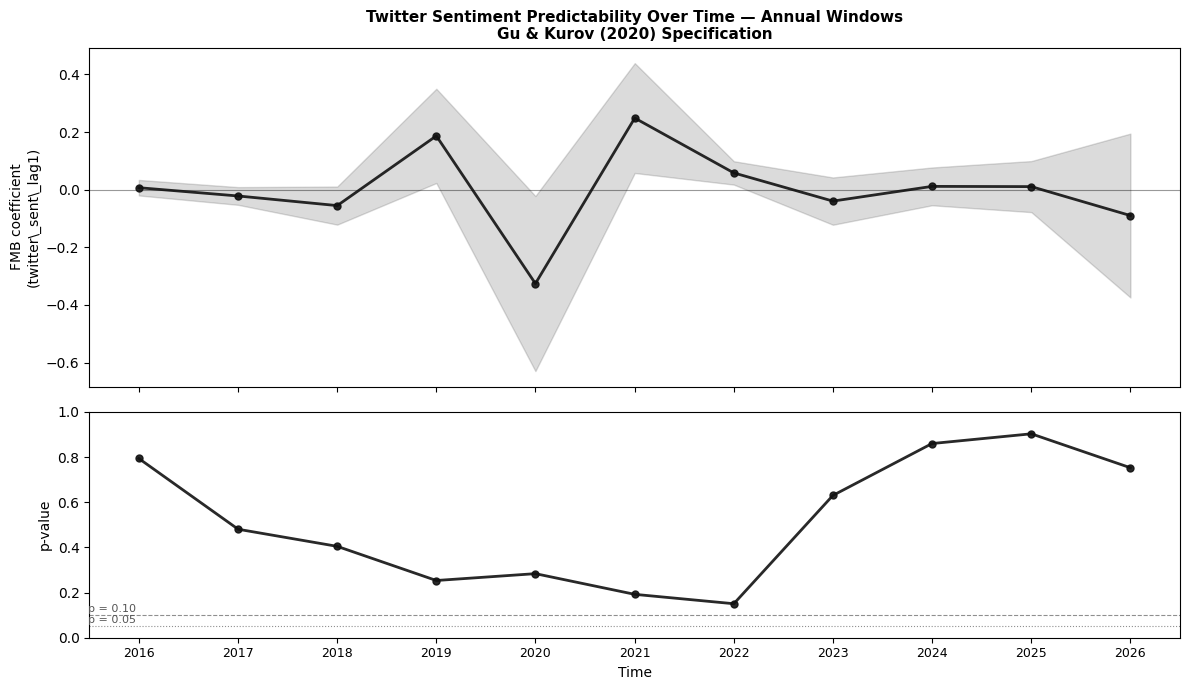

Saved /content/Capstone/output/figures/gk_temporal_quarterly.png


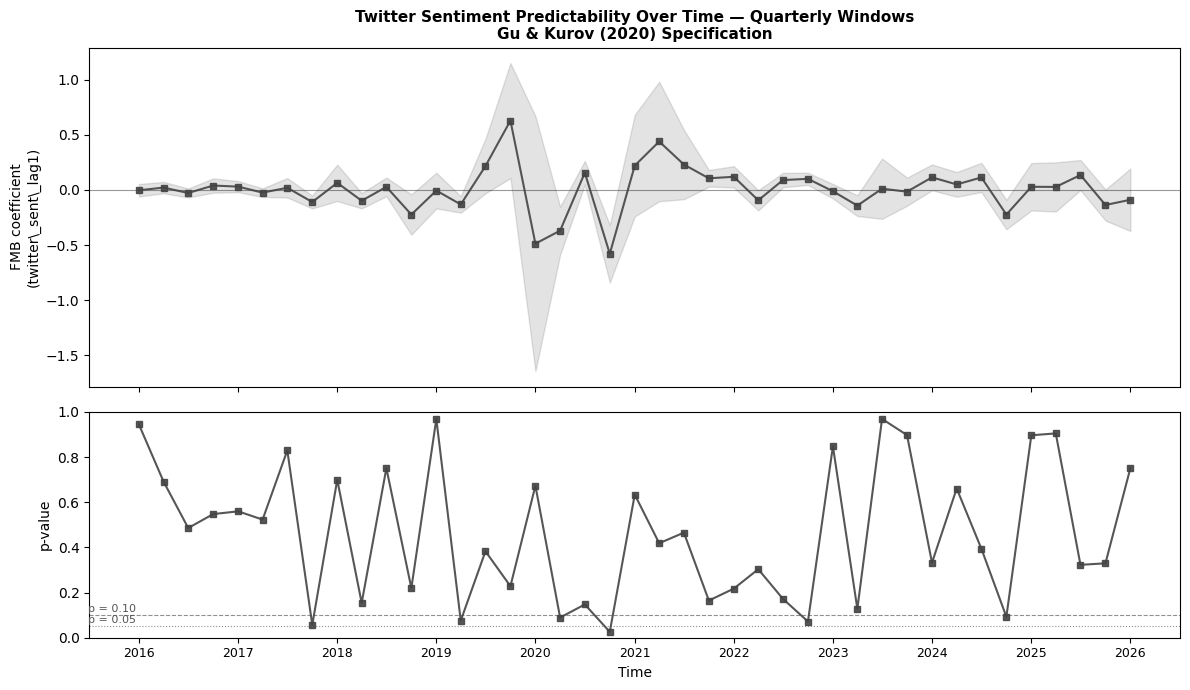

Saved /content/Capstone/output/figures/gk_temporal_monthly.png


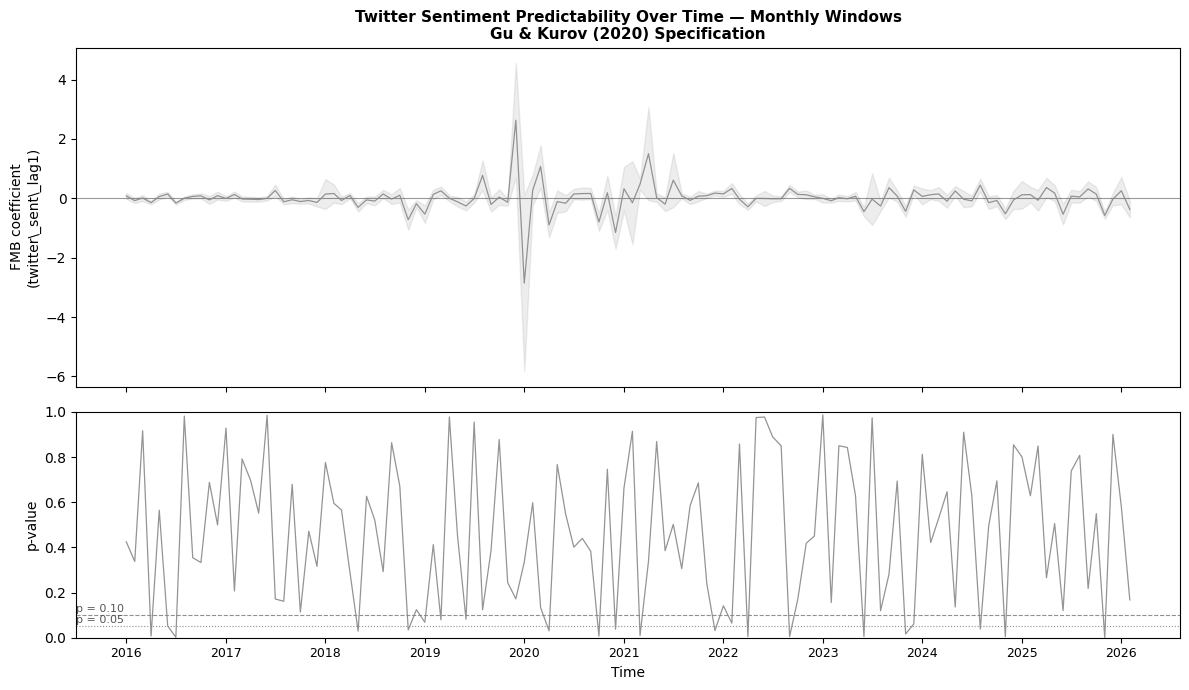

In [38]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import os

fig_path = REPO_DIR + '/output/figures/'
os.makedirs(fig_path, exist_ok=True)

def prep(df):
    d = df.copy()
    d['t'] = pd.to_datetime(d['window_start'])
    d = d.dropna(subset=['fmb_coef', 'fmb_se', 'fmb_pval'])
    return d.sort_values('t')

def plot_temporal(df, freq_label, color, lw, marker, out_name):
    d = prep(df)
    if d.empty:
        print(f'No valid data for {freq_label}.')
        return

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 7), sharex=True,
        gridspec_kw={'height_ratios': [3, 2]}
    )
    fig.subplots_adjust(hspace=0.25)

    t    = d['t']
    coef = d['fmb_coef']
    se   = d['fmb_se']
    pval = d['fmb_pval']

    # ── Panel 1: coefficient ± 1 SE ────────────────────────────────────
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
    ax1.plot(t, coef, color=color, linewidth=lw,
             marker=marker, markersize=5 if marker else 0, alpha=0.9,
             label=freq_label)
    ax1.fill_between(t, coef - se, coef + se, color=color, alpha=0.15)

    ax1.set_ylabel('FMB coefficient\n(twitter\_sent\_lag1)', fontsize=10)
    ax1.set_title(
        f'Twitter Sentiment Predictability Over Time — {freq_label} Windows\n'
        f'Gu & Kurov (2020) Specification',
        fontsize=11, fontweight='bold'
    )
    ax1.tick_params(axis='x', labelsize=9)

    # ── Panel 2: p-value ───────────────────────────────────────────────
    ax2.axhline(0.10, color='#444444', linewidth=0.8, linestyle='--', alpha=0.6,
                label='p = 0.10')
    ax2.axhline(0.05, color='#444444', linewidth=0.8, linestyle=':',  alpha=0.6,
                label='p = 0.05')

    # Reference line labels — placed at the left edge of the data
    t_left = t.iloc[0] - pd.Timedelta(days=10)
    ax2.text(t_left, 0.105, 'p = 0.10', fontsize=8, color='#555555',
             va='bottom', ha='right')
    ax2.text(t_left, 0.055, 'p = 0.05', fontsize=8, color='#555555',
             va='bottom', ha='right')

    ax2.plot(t, pval, color=color, linewidth=lw,
             marker=marker, markersize=5 if marker else 0, alpha=0.9)
    ax2.set_ylim(0, 1.0)
    ax2.set_ylabel('p-value', fontsize=10)
    ax2.set_xlabel('Time', fontsize=10)

    # Shared x-axis formatting
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.tick_params(axis='x', labelsize=9)

    fig.tight_layout()
    save_path = fig_path + out_name
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

# ── Three separate figures ─────────────────────────────────────────────────
plot_temporal(annual_df,    'Annual',    '#111111', 2.0, 'o',  'gk_temporal_annual.png')
plot_temporal(quarterly_df, 'Quarterly', '#444444', 1.5, 's',  'gk_temporal_quarterly.png')
plot_temporal(monthly_df,   'Monthly',   '#888888', 0.9, None, 'gk_temporal_monthly.png')


## 10. LaTeX exports
Generates four publication-ready LaTeX outputs:
1. **Figure** — `\includegraphics` wrapper for the temporal plot
2. **Summary statistics** — mean, SD, min, max of key variables across the full panel
3. **FMB regression table** — coefficient, SE, p-value by year (annual frequency)
4. **Long-short strategy table** — Sharpe, annualized return, win rate by year

In [40]:
import os
TEX_OUT = REPO_DIR + '/output/'
os.makedirs(TEX_OUT, exist_ok=True)

def st(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fmt(v, decimals=4):
    return f'{v:.{decimals}f}' if not pd.isna(v) else '---'

# ── 1. FIGURES (three separate) ──────────────────────────────────────────
FREQ_FIGS = [
    ('annual',    'gk_temporal_annual.png',
     'Annual windows (one observation per calendar year). '
     r'Bandwidth = 5 lags; minimum cross-section $N = 30$.'),
    ('quarterly', 'gk_temporal_quarterly.png',
     'Quarterly windows. '
     r'Bandwidth = 4 lags; minimum cross-section $N = 20$.'),
    ('monthly',   'gk_temporal_monthly.png',
     'Monthly windows. '
     r'Bandwidth = 3 lags; minimum cross-section $N = 15$.'),
]

tex_fig_parts = []
for freq, fname, note in FREQ_FIGS:
    tex_fig_parts.append(
        r'\begin{figure}[htbp]' + '\n'
        r'\centering' + '\n'
        f'\\includegraphics[width=\\linewidth]{{figures/{fname}}}' + '\n'
        r'\caption{Twitter Sentiment Predictability Over Time --- '
        f'Gu \\& Kurov (2020) Specification ({freq.capitalize()} windows). '
        r'Top panel: Fama-MacBeth coefficient on \texttt{twitter\_sent\_lag1} '
        r'with $\pm$1 SE band. Bottom panel: associated $p$-value; dashed lines '
        r'at $p = 0.10$ and $p = 0.05$. '
        + note + r'}' + '\n'
        f'\\label{{fig:gk_temporal_{freq}}}' + '\n'
        r'\end{figure}'
    )

tex_fig = '\n\n'.join(tex_fig_parts)
with open(TEX_OUT + 'gk_temporal_fig.tex', 'w') as f:
    f.write(tex_fig)
print('Saved gk_temporal_fig.tex  (3 figure environments)')


# ── 2. SUMMARY STATISTICS ──────────────────────────────────────────────────
sum_vars = {
    'return\_oo':          'return_oo',
    'twitter\_sent':       'twitter_sent',
    'news\_sent':          'news_sent',
    'vol\_rs':             'vol_rs',
    'abnorm\_vol':         'abnorm_vol',
    'log\_mkt\_cap':      'log_mkt_cap',
}
if HAS_SPREAD:
    sum_vars['bid\_ask\_spread'] = 'bid_ask_spread'
if HAS_ADJ_RETURN:
    sum_vars['return\_oo\_adj'] = 'return_oo_adj'

sum_rows = []
for label, col in sum_vars.items():
    if col not in long.columns: continue
    s = long[col].dropna()
    sum_rows.append(
        f'  {label} & {fmt(s.mean())} & {fmt(s.std())} & '
        f'{fmt(s.min())} & {fmt(s.max())} & {len(s):,} \\\\'
    )

tex_sumstats = (
    r'\begin{table}[htbp]' + '\n'
    r'\centering' + '\n'
    r'\caption{Summary Statistics --- Full Panel (2016--2026)}' + '\n'
    r'\label{tab:sumstats}' + '\n'
    r'\begin{tabular}{lrrrrr}' + '\n'
    r'\hline\hline' + '\n'
    r'Variable & Mean & SD & Min & Max & $N$ \\' + '\n'
    r'\hline' + '\n'
    + '\n'.join(sum_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{6}{p{0.95\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Daily firm-level panel. return\_oo = open-to-open return (\%). '
    + r'vol\_rs = Rogers-Satchell realized volatility. '
    + r'abnorm\_vol = abnormal volume (\% deviation from ticker mean). '
    + r'log\_mkt\_cap = log market capitalization. '
    + (r'return\_oo\_adj = Fama-French-Carhart 4-factor residual.' if HAS_ADJ_RETURN else '') + r'} \\' + '\n'
    + r'\end{tabular}' + '\n'
    + r'\end{table}'
)
with open(TEX_OUT + 'gk_temporal_sumstats.tex', 'w') as f:
    f.write(tex_sumstats)
print('Saved gk_temporal_sumstats.tex')

# ── 3. FMB REGRESSION TABLE (annual) ───────────────────────────────────────
ann = annual_df.copy()

fmb_rows = []
for _, r in ann.iterrows():
    c  = fmt(r['fmb_coef'])
    s  = fmt(r['fmb_se'])
    pv = fmt(r['fmb_pval'])
    sig = st(r['fmb_pval'])
    n  = f"{int(r['n_obs']):,}" if not pd.isna(r['n_obs']) else '---'
    fmb_rows.append(
        f"  {r['window_label']} & ${c}{sig}$ & $({s})$ & ${pv}$ & {n} \\\\"
    )

tex_fmb = (
    r'\begin{table}[htbp]' + '\n'
    r'\centering' + '\n'
    r'\caption{FMB Return Predictability by Year --- '
    r'Gu \& Kurov (2020) Specification}' + '\n'
    r'\label{tab:gk_fmb_annual}' + '\n'
    r'\begin{tabular}{lcccc}' + '\n'
    r'\hline\hline' + '\n'
    r'Year & Coef & (SE) & $p$-value & $N$ \\' + '\n'
    r'\hline' + '\n'
    + '\n'.join(fmb_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{5}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Fama-MacBeth regression with Newey-West SEs (bandwidth = 5). '
    + f'Dependent variable: \\texttt{{{DEP_VAR}}}. '
    + r'Treatment: \texttt{twitter\_sent\_lag1}. '
    + r'Controls: 5 lags each of return, abnorm\_vol, vol\_rs, log\_mkt\_cap'
    + (r', bid\_ask\_spread' if HAS_SPREAD else '') + r'. '
    + r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.} \\' + '\n'
    + r'\end{tabular}' + '\n'
    + r'\end{table}'
)
with open(TEX_OUT + 'gk_temporal_fmb.tex', 'w') as f:
    f.write(tex_fmb)
print('Saved gk_temporal_fmb.tex')

# ── 4. LONG-SHORT STRATEGY TABLE (annual) ──────────────────────────────────
ls_rows = []
for _, r in ann.iterrows():
    ls_rows.append(
        f"  {r['window_label']} "
        f"& {fmt(r['ls_mean_daily'], 4)} "
        f"& {fmt(r['ls_ann_return'], 2)} "
        f"& {fmt(r['ls_sharpe'], 2)} "
        f"& {fmt(r['ls_win_rate'], 3)} "
        f"& {int(r['ls_n_days']) if not pd.isna(r['ls_n_days']) else '---'} \\\\"
    )

tex_ls = (
    r'\begin{table}[htbp]' + '\n'
    r'\centering' + '\n'
    r'\caption{Long-Short Strategy Performance by Year --- '
    r'Gu \& Kurov (2020) Specification}' + '\n'
    r'\label{tab:gk_ls_annual}' + '\n'
    r'\begin{tabular}{lccccc}' + '\n'
    r'\hline\hline' + '\n'
    r'Year & Mean Daily (\%) & Ann. Return (\%) & Sharpe & Win Rate & Days \\' + '\n'
    r'\hline' + '\n'
    + '\n'.join(ls_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{6}{p{0.95\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Daily long-short portfolio. Long (short) = top (bottom) decile of contemporaneous '
    + r'Twitter sentiment. 24-hour holding period (open-to-open). '
    + r'Sharpe ratio annualized assuming 252 trading days. Before transaction costs. '
    + r'Gu \& Kurov (2020) report Sharpe = 3.17 over Jan 2015--Feb 2017.} \\' + '\n'
    + r'\end{tabular}' + '\n'
    + r'\end{table}'
)
with open(TEX_OUT + 'gk_temporal_ls.tex', 'w') as f:
    f.write(tex_ls)
print('Saved gk_temporal_ls.tex')

print('\nAll LaTeX outputs written to', TEX_OUT)

Saved gk_temporal_fig.tex  (3 figure environments)
Saved gk_temporal_sumstats.tex
Saved gk_temporal_fmb.tex
Saved gk_temporal_ls.tex

All LaTeX outputs written to /content/Capstone/output/


## 9. Save output CSVs and push to GitHub

In [39]:
monthly_df.to_csv(   DATA_OUT + 'gk_temporal_monthly.csv',   index=False)
quarterly_df.to_csv( DATA_OUT + 'gk_temporal_quarterly.csv', index=False)
annual_df.to_csv(    DATA_OUT + 'gk_temporal_annual.csv',    index=False)
print('Saved:')
print(f'  {DATA_OUT}gk_temporal_monthly.csv   ({len(monthly_df)} rows x {len(monthly_df.columns)} cols)')
print(f'  {DATA_OUT}gk_temporal_quarterly.csv ({len(quarterly_df)} rows x {len(quarterly_df.columns)} cols)')
print(f'  {DATA_OUT}gk_temporal_annual.csv    ({len(annual_df)} rows x {len(annual_df.columns)} cols)')

import os, subprocess
os.chdir(REPO_DIR)
subprocess.run(['git','config','user.email','althompson9@dons.usfca.edu'], check=True)
subprocess.run(['git','config','user.name', 'Ashley Thompson'],            check=True)
subprocess.run(['git', 'add',
    'data/processed/gk_temporal_monthly.csv',
    'data/processed/gk_temporal_quarterly.csv',
    'data/processed/gk_temporal_annual.csv',
    'output/figures/gk_temporal_annual.png',
    'output/figures/gk_temporal_quarterly.png',
    'output/figures/gk_temporal_monthly.png',
    'output/gk_temporal_fig.tex',
    'output/gk_temporal_sumstats.tex',
    'output/gk_temporal_fmb.tex',
    'output/gk_temporal_ls.tex'], check=True)

subprocess.run(['git','commit','-m','Long term look at sentiment influence using Gu & Kurov methodology. 2016-2026 panel.'], check=True)
subprocess.run(['git','push',
    f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git','main'], check=True)
print('Pushed to GitHub.')

Saved:
  /content/Capstone/data/processed/gk_temporal_monthly.csv   (122 rows x 35 cols)
  /content/Capstone/data/processed/gk_temporal_quarterly.csv (41 rows x 35 cols)
  /content/Capstone/data/processed/gk_temporal_annual.csv    (11 rows x 35 cols)
Pushed to GitHub.
